In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

In [ ]:
current_folder = os.getcwd()
print(current_folder)

In [12]:
from ipyfilechooser import FileChooser

# Create and display a FileChooser widget
fc = FileChooser(f"{os.getcwd()}/../documents")  # Change this to your folder path
display(fc)

FileChooser(path='/Users/jaki/Git/teaching/proving-service/benchmarks/documents', filename='', title='', show_…

In [27]:
# Read all CSV files from the folder
csv_files = {}
for file in os.listdir(fc.selected_path):
    if file.endswith('.csv'):
        file_name = Path(file).stem  # Get filename without extension
        file_path = os.path.join(fc.selected_path, file)
        csv_files[file_name] = pd.read_csv(file_path,index_col=0)

print(csv_files.keys())

dict_keys(['bench_tree_aggregation_baseline_precompiles', 'bench_tree_aggregation_lazy', 'bench_composition_baseline', 'bench_proofaggregation_baseline_precompiles', 'bench_proofaggregation_lazy', 'bench_composition_lazy', 'bench_composition_baseline_precompiles'])


In [28]:
df = pd.DataFrame()
for k,v in csv_files.items():
    df_k = v.set_index(pd.MultiIndex.from_product([[k], v.index], names=['source', 'run_id']))
    df = pd.concat([df, df_k], axis=0)

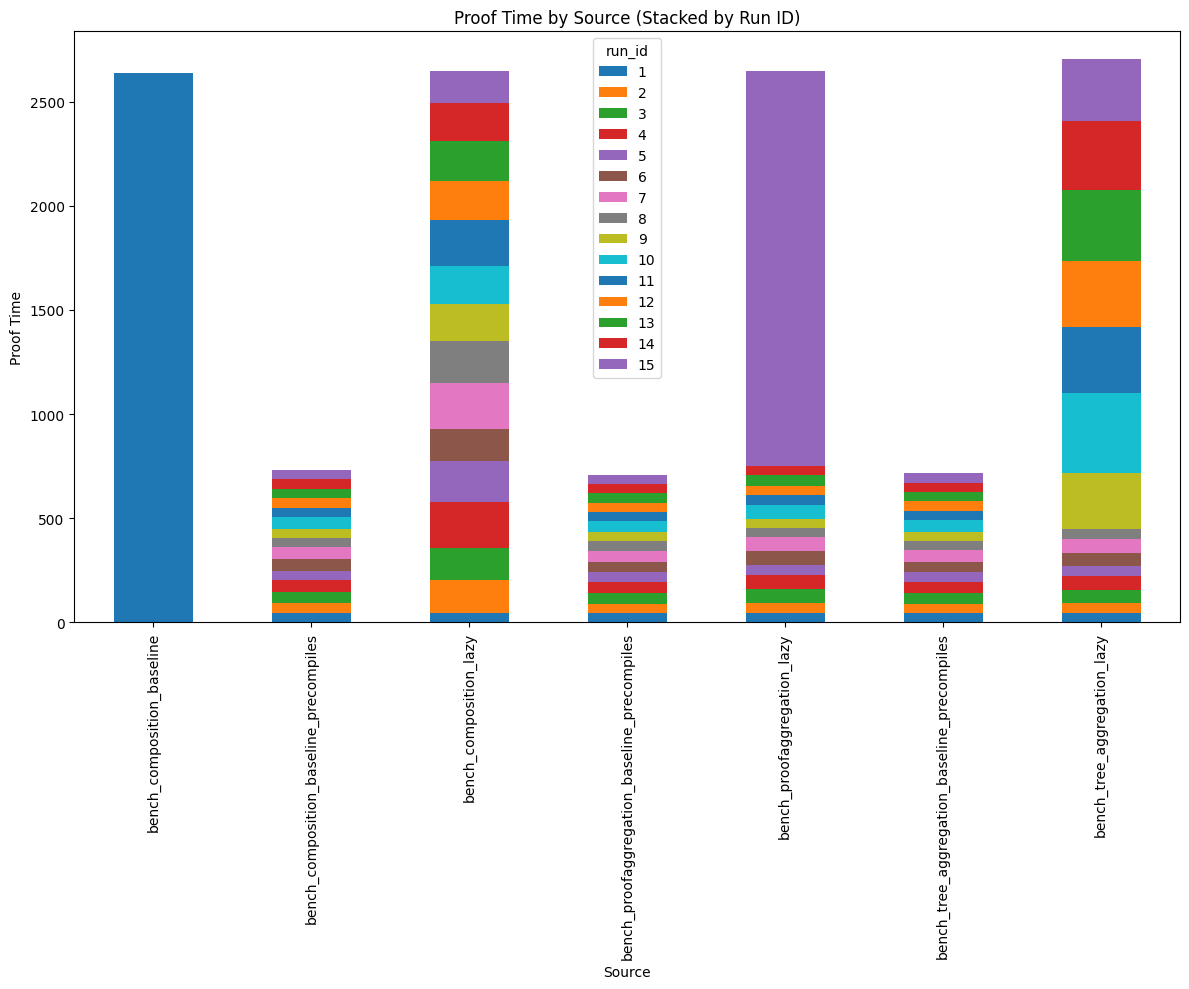

In [58]:
df.groupby("source")["proof_time"].apply(lambda x: x.groupby(level="run_id").sum()).unstack(fill_value=0).plot(kind='bar', stacked=True, figsize=(12, 10))
plt.xlabel("Source")
plt.ylabel("Proof Time")
plt.title("Proof Time by Source (Stacked by Run ID)")
plt.tight_layout()
plt.show()